In [3]:
import csv
from collections import Counter

import arxiv
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm


class Parser:
    def __init__(self, query: str = "cat:cs.AI", max_results: int = 500):
        self.query = query
        self.max_results = max_results
        self.client = arxiv.Client()

    def fetch_data(self) -> list[dict]:
        """Fetch articles from arXiv API"""
        search = arxiv.Search(
            query=self.query,
            max_results=self.max_results,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )

        articles = []
        for result in tqdm(self.client.results(search), desc="Downloading articles"):
            articles.append({
                "title": result.title,
                "authors": "; ".join([a.name for a in result.authors]),
                "abstract": result.summary.replace('\n', ' '),
                "published": result.published.date().isoformat()
            })
        return articles


class CSVHandler:
    def __init__(self, filename: str):
        self.filename = filename

    def save_to_csv(self, data: list[dict]) -> None:
        """Save list of dictionaries to CSV"""
        with open(self.filename, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=data[0].keys())
            writer.writeheader()
            writer.writerows(data)

    def load_from_csv(self) -> pd.DataFrame:
        """Load CSV to pandas DataFrame"""
        return pd.read_csv(self.filename)


In [4]:
nltk.download('stopwords')

class KeywordExtractor:
    def __init__(self, max_features: int = 1500, ngram_range: tuple = (1, 2)):
        self.stop_words = set(stopwords.words('english'))
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            stop_words='english',
            ngram_range=ngram_range,
            min_df=5,  
            max_df=0.85
        )

    def process_text(self, df: pd.DataFrame) -> pd.DataFrame:
        """Prepare text data for analysis"""
        df['text'] = df['title'] + ' ' + df['abstract']
        return df

    def extract_keywords(self, df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
        """Extract keywords using TF-IDF"""
        tfidf_matrix = self.vectorizer.fit_transform(df['text'])
        feature_names = self.vectorizer.get_feature_names_out()

        df['keywords'] = ''
        for i in tqdm(range(len(df)), desc="Extracting keywords"):
            tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray().flatten())
            sorted_words = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)[:top_n]
            df.at[i, 'keywords'] = ', '.join([word for word, _ in sorted_words])

        return df


class ResearchVisualizer:
    @staticmethod
    def plot_top_keywords(df: pd.DataFrame, top_n: int = 20) -> None:
        """Visualize most frequent keywords"""
        all_keywords = [kw for sublist in df['keywords'].str.split(', ') for kw in sublist]
        top_keywords = Counter(all_keywords).most_common(top_n)

        plt.figure(figsize=(12, 8))
        plt.barh([kw[0] for kw in top_keywords], [kw[1] for kw in top_keywords])
        plt.title(f'Top-{top_n} Keywords in AI Research Papers')
        plt.xlabel('Frequency')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('ai_keywords.png', dpi=300)
        plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ggelmetdinov\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# 1. Загрузка данных
parser = Parser(max_results=500)
articles = parser.fetch_data()

# 2. Сохранение в CSV
csv_handler = CSVHandler('ai_papers.csv')
csv_handler.save_to_csv(articles)

In [6]:
# 3. Загрузка данных и обработка
df = csv_handler.load_from_csv()
df

,title,authors,abstract,published
0,VCR-Bench: A Comprehensive Evaluation Framewor...,Yukun Qi; Yiming Zhao; Yu Zeng; Xikun Bao; Wen...,The advancement of Chain-of-Thought (CoT) reas...,2025-04-10
1,GenEAva: Generating Cartoon Avatars with Fine-...,Hao Yu; Rupayan Mallick; Margrit Betke; Sarah ...,Cartoon avatars have been widely used in vario...,2025-04-10
2,"We Are All Creators: Generative AI, Collective...",Jordi Linares-Pellicer; Juan Izquierdo-Domenec...,Generative AI presents a profound challenge to...,2025-04-10
3,Note on the identification of total effect in ...,Clément Yvernes,"In this note, we discuss the identifiability o...",2025-04-10
4,The Urban Impact of AI: Modeling Feedback Loop...,Giovanni Mauro; Marco Minici; Luca Pappalardo,Next-venue recommender systems are increasingl...,2025-04-10
...,...,...,...,...
495,CORTEX-AVD: A Framework for CORner Case Testin...,Gabriel Kenji Godoy Shimanuki; Alexandre Morei...,Autonomous Vehicles (AVs) aim to improve traff...,2025-04-04
496,V-CEM: Bridging Performance and Intervenabilit...,Francesco De Santis; Gabriele Ciravegna; Phili...,Concept-based eXplainable AI (C-XAI) is a rapi...,2025-04-04
497,OLAF: An Open Life Science Analysis Framework ...,Dylan Riffle; Nima Shirooni; Cody He; Manush M...,OLAF (Open Life Science Analysis Framework) is...,2025-04-04
498,"GREATERPROMPT: A Unified, Customizable, and Hi...",Wenliang Zheng; Sarkar Snigdha Sarathi Das; Yu...,LLMs have gained immense popularity among rese...,2025-04-04


In [7]:
# 4. Извлечение ключевых слов
processor = KeywordExtractor()
df = processor.process_text(df)
df = processor.extract_keywords(df)
df.sample(5)

Extracting keywords: 100%|██████████| 500/500 [00:00<00:00, 619.91it/s]


,title,authors,abstract,published,text,keywords
405,Enhance Then Search: An Augmentation-Search St...,Jiancheng Pan; Yanxing Liu; Xiao He; Long Peng...,Foundation models pretrained on extensive data...,2025-04-06,Enhance Then Search: An Augmentation-Search St...,"object detection, domain, foundation, shot, se..."
467,"My Life in Artificial Intelligence: People, an...",Kees van Deemter,"In this very personal workography, I relate my...",2025-04-05,"My Life in Artificial Intelligence: People, an...","life, artificial intelligence, ai, artificial,..."
210,Physics-aware generative models for turbulent ...,Nikolaj T. Mücke; Benjamin Sanderse,Generative models have demonstrated remarkable...,2025-04-08,Physics-aware generative models for turbulent ...,"stochastic, generative models, generative, ene..."
480,Mapping at First Sense: A Lightweight Neural N...,Haojia Gao; Haohua Que; Kunrong Li; Weihao Sha...,Autonomous exploration in unknown environments...,2025-04-05,Mapping at First Sense: A Lightweight Neural N...,"exploration, environments, frontier, method, n..."
410,LoopGen: Training-Free Loopable Music Generation,Davide Marincione; Giorgio Strano; Donato Cris...,Loops--short audio segments designed for seaml...,2025-04-06,LoopGen: Training-Free Loopable Music Generati...,"music, audio, short, loop, styles, generative,..."


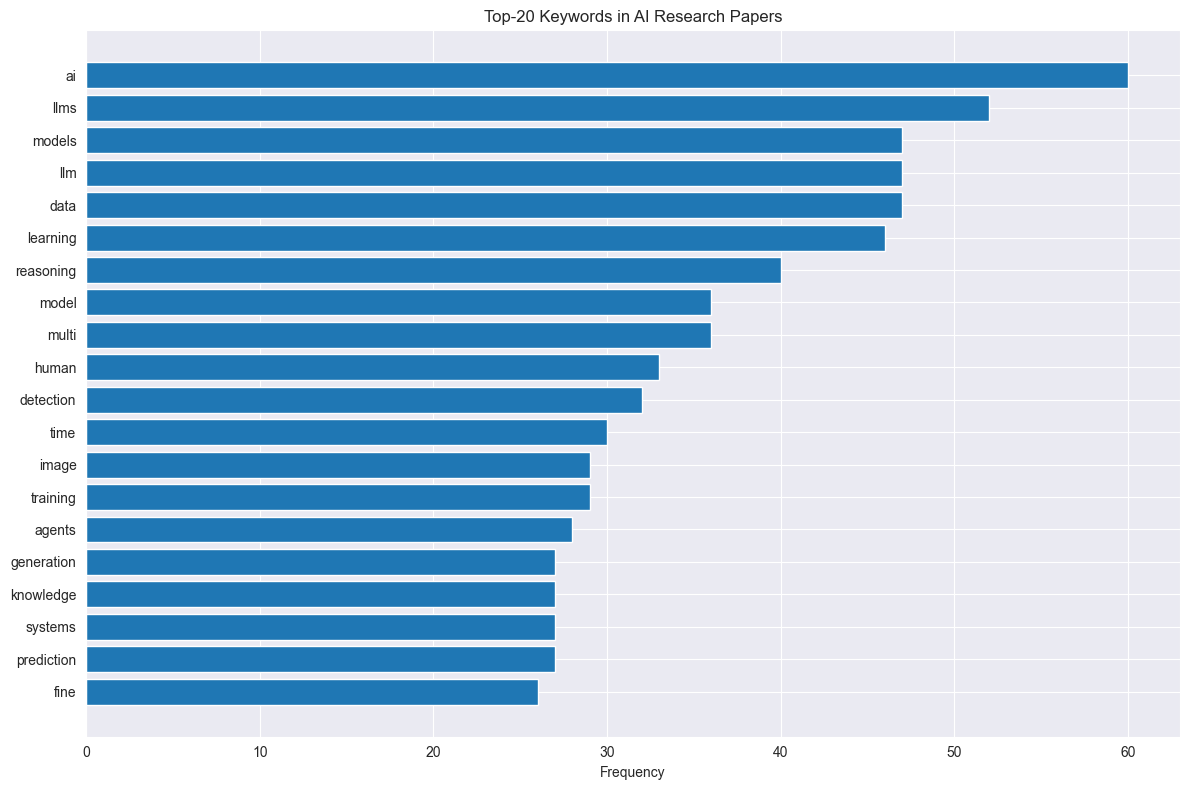

In [8]:

# 5. Сохранение результатов
csv_handler.filename = 'ai_papers_with_keywords.csv'
df.to_csv(csv_handler.filename, index=False)

# 6. Визуализация
ResearchVisualizer.plot_top_keywords(df)

In [14]:
import networkx as nx
import cosmograph
from itertools import combinations
from tabulate import tabulate  # Для красивого вывода таблиц


class KeywordNetworkAnalyzer:
    def __init__(self, csv_path: str):
        self.df = pd.read_csv(csv_path)
        self.df['keywords'] = self.df['keywords'].str.split(', ')
        self.G = nx.Graph()
        self.partition = None
        self.modularity = None
        self.community_stats = None

    def detect_communities(self):
        communities = nx.community.louvain_communities(
            self.G, 
            weight='weight',
            resolution=0.9,
            seed=42,
            threshold=0.01
        )
        
        communities = self._merge_small_communities(communities, min_size=3)

        all_nodes = set(self.G.nodes())
        clustered_nodes = set().union(*communities)
        orphans = all_nodes - clustered_nodes
        
        for node in orphans:
            neighbors = list(self.G.neighbors(node))
            if neighbors:
                target = next((c for c in communities if neighbors[0] in c), None)
                if target:
                    target.add(node)
        
        self.partition = {node: cid for cid, nodes in enumerate(communities) for node in nodes}
        self.modularity = nx.community.modularity(self.G, communities, weight='weight')
        
        # Собираем статистику
        self._calculate_community_stats(communities)
        return self.partition

    def _merge_small_communities(self, communities, min_size=3):
        """Объединение мелких кластеров с гарантией min_size"""
        # Преобразуем в множества и сортируем по убыванию размера
        communities = sorted([set(c) for c in communities], key=len, reverse=True)
        merged = []
        
        # Сначала обрабатываем все кластеры >= min_size
        for cluster in communities:
            if len(cluster) >= min_size:
                merged.append(cluster)
        
        # Обрабатываем мелкие кластеры
        small_clusters = [c for c in communities if len(c) < min_size]
        for sc in small_clusters:
            best_match = None
            max_overlap = 0
            
            # Ищем кластер с максимальным перекрытием по связям
            for target in merged:
                overlap = sum(1 for node in sc if any(self.G.has_edge(node, t) for t in target))
                if overlap > max_overlap:
                    max_overlap = overlap
                    best_match = target
                    
            if best_match is not None:
                best_match.update(sc)
            else:
                # Если связей нет - объединяем с ближайшим по тематике
                merged.append(sc)
        
        # Гарантируем min_size через принудительное объединение
        final_clusters = []
        current_cluster = set()
        for cluster in sorted(merged, key=len, reverse=True):
            if len(current_cluster | cluster) <= min_size * 2:
                current_cluster.update(cluster)
            else:
                if len(current_cluster) >= min_size:
                    final_clusters.append(current_cluster)
                current_cluster = set(cluster)
        
        if current_cluster:
            final_clusters.append(current_cluster)
            
        return final_clusters
    
    def _calculate_community_stats(self, communities):
        stats = []
        
        # Глобальные метрики центральности
        degree_centrality = nx.degree_centrality(self.G)
        betweenness = nx.betweenness_centrality(self.G, weight='weight')
        eigenvector = nx.eigenvector_centrality(self.G, weight='weight', max_iter=1000)

        for cid, nodes in enumerate(communities):
            subgraph = self.G.subgraph(nodes)
            
            # Размер сообщества
            size = len(nodes)
            
            # Центральности для сообщества
            avg_degree = sum(degree_centrality[n] for n in nodes) / size
            avg_betweenness = sum(betweenness[n] for n in nodes) / size
            avg_eigen = sum(eigenvector[n] for n in nodes) / size
            
            # Топ-5 ключевых слов
            top_nodes = sorted(
                nodes, 
                key=lambda x: degree_centrality[x], 
                reverse=True
            )[:5]
            
            stats.append({
                'cluster_id': cid,
                'size': size,
                'avg_degree': avg_degree,
                'avg_betweenness': avg_betweenness,
                'avg_eigenvector': avg_eigen,
                'top_keywords': ", ".join(top_nodes)
            })

        self.community_stats = pd.DataFrame(stats)

    def print_summary(self):
        """Расширенная сводка с топ-10 по всем метрикам"""
        if self.community_stats is None:
            raise ValueError("Сначала выполните detect_communities()")

        # Общая статистика
        general_stats = [
            ["Всего кластеров", len(self.community_stats)],
            ["Модулярность", f"{self.modularity:.3f}"],
            ["Общее ключевых слов", self.community_stats['size'].sum()],
            ["Средний размер кластера", f"{self.community_stats['size'].mean():.1f}"],
            ["Макс. размер", f"{self.community_stats['size'].max()}"],
            ["Мин. размер", f"{self.community_stats['size'].min()}"]
        ]

        # Статистика по метрикам
        metric_stats = []
        for metric in ['avg_degree', 'avg_betweenness', 'avg_eigenvector']:
            stats = self.community_stats[metric].describe()
            metric_stats.append([
                metric.replace('avg_', '').capitalize(),
                f"{stats['mean']:.3f}",
                f"{stats['max']:.3f}",
                f"{stats['min']:.3f}",
                f"{stats['std']:.3f}"
            ])

        # Топ-10 по всем метрикам
        top_tables = []
        for metric, title in [
            ('avg_degree', "Топ-10 по степени центральности"),
            ('avg_betweenness', "Топ-10 по посреднической центральности"), 
            ('avg_eigenvector', "Топ-10 по собственной центральности")
        ]:
            top_df = self.community_stats.nlargest(10, metric)[[
                'cluster_id', 'size', metric, 'top_keywords'
            ]].rename(columns={metric: 'value'})
            
            top_df['value'] = top_df['value'].apply(lambda x: f"{x:.4f}")
            top_tables.append(
                f"\n{title}\n" + 
                tabulate(top_df, headers='keys', tablefmt='psql', showindex=False)
            )

        # Формирование итогового отчета
        report = [
            "\n=== ОБЩАЯ СТАТИСТИКА ===",
            tabulate(general_stats, tablefmt='psql'),
            "\n=== СТАТИСТИКА ПО МЕТРИКАМ ===",
            tabulate(metric_stats, 
                    headers=['Метрика', 'Среднее', 'Макс', 'Мин', 'Стд.откл'], 
                    tablefmt='psql'),
            *top_tables
        ]

        print("\n".join(report))

    def get_detailed_stats(self) -> pd.DataFrame:
        """Возвращает полную статистику по кластерам"""
        return self.community_stats

    def plot_community_distribution(self):
        """Визуализация распределения кластеров"""
        plt.figure(figsize=(1, 1))
        self.community_stats['size'].plot.hist(bins=10, edgecolor='black')
        plt.title('Распределение размеров кластеров')
        plt.xlabel('Количество ключевых слов')
        plt.ylabel('Частота')
        plt.grid(True)
        plt.show()

    def build_cooccurrence_network(self, min_weight: int = 2):
        """Строит сеть совместной встречаемости ключевых слов"""
        cooc_counts = {}
        
        # Считаем совместные появления
        for keywords in self.df['keywords']:
            for pair in combinations(sorted(keywords), 2):
                cooc_counts[pair] = cooc_counts.get(pair, 0) + 1

        # Добавляем ребра с фильтрацией
        for (kw1, kw2), count in cooc_counts.items():
            if count >= min_weight:
                self.G.add_edge(kw1, kw2, weight=count)

        # Добавляем изолированные узлы
        all_keywords = set(kw for sublist in self.df['keywords'] for kw in sublist)
        self.G.add_nodes_from(all_keywords)

    def visualize_with_cosmograph(self):
        """Визуализация сети с помощью Cosmograph"""
        nodes = [{
            'id': kw, 
            'name': kw, 
            'cluster': self.partition[kw],
            'degree': self.G.degree(kw)
        } for kw in self.G.nodes()]

        edges = [{
            'source': u, 
            'target': v, 
            'weight': d['weight']
        } for u, v, d in self.G.edges(data=True)]

        cosmograph.plot(
            nodes=nodes,
            edges=edges,
            node_color_by='cluster',
            node_size_by='degree',
            edge_width_by='weight',
            config={
                'title': f'AI Research Keywords Network (Modularity: {self.modularity:.2f})',
                'node_size_range': [3, 15],
                'edge_curvature': 0.2
            }
        )

    def visualize_with_networkx(self):
        """Альтернативная визуализация с NetworkX"""
        plt.figure(figsize=(20, 15))
        pos = nx.spring_layout(self.G, k=0.15)
        
        nx.draw_networkx_nodes(
            self.G, pos,
            node_size=50,
            cmap=plt.cm.tab20,
            node_color=[self.partition[node] for node in self.G.nodes()]
        )
        
        nx.draw_networkx_edges(
            self.G, pos,
            edge_color='gray',
            width=0.3,
            alpha=0.5
        )
        
        plt.title(f"AI Keywords Network (Modularity: {self.modularity:.2f})")
        plt.axis('off')
        plt.show()

In [15]:

analyzer = KeywordNetworkAnalyzer('ai_papers_with_keywords.csv')

# Построение сети (фильтр слабых связей)
analyzer.build_cooccurrence_network(min_weight=2)

# Кластеризация и оценка
partition = analyzer.detect_communities()
print(f"Найдено кластеров: {len(set(partition.values()))}")
print(f"Модулярность: {analyzer.modularity:.3f}")

Найдено кластеров: 80
Модулярность: 0.436


In [16]:
analyzer.print_summary()


=== ОБЩАЯ СТАТИСТИКА ===
+-------------------------+----------+
| Всего кластеров         |   80     |
| Модулярность            |    0.436 |
| Общее ключевых слов     | 1381     |
| Средний размер кластера |   17.3   |
| Макс. размер            |  178     |
| Мин. размер             |    3     |
+-------------------------+----------+

=== СТАТИСТИКА ПО МЕТРИКАМ ===
+-------------+-----------+--------+-------+------------+
| Метрика     |   Среднее |   Макс |   Мин |   Стд.откл |
|-------------+-----------+--------+-------+------------|
| Degree      |     0.001 |  0.007 |     0 |      0.002 |
| Betweenness |     0     |  0.001 |     0 |      0     |
| Eigenvector |     0.002 |  0.022 |     0 |      0.005 |
+-------------+-----------+--------+-------+------------+

Топ-10 по степени центральности
+--------------+--------+---------+----------------------------------------------------------------------+
|   cluster_id |   size |   value | top_keywords                                    

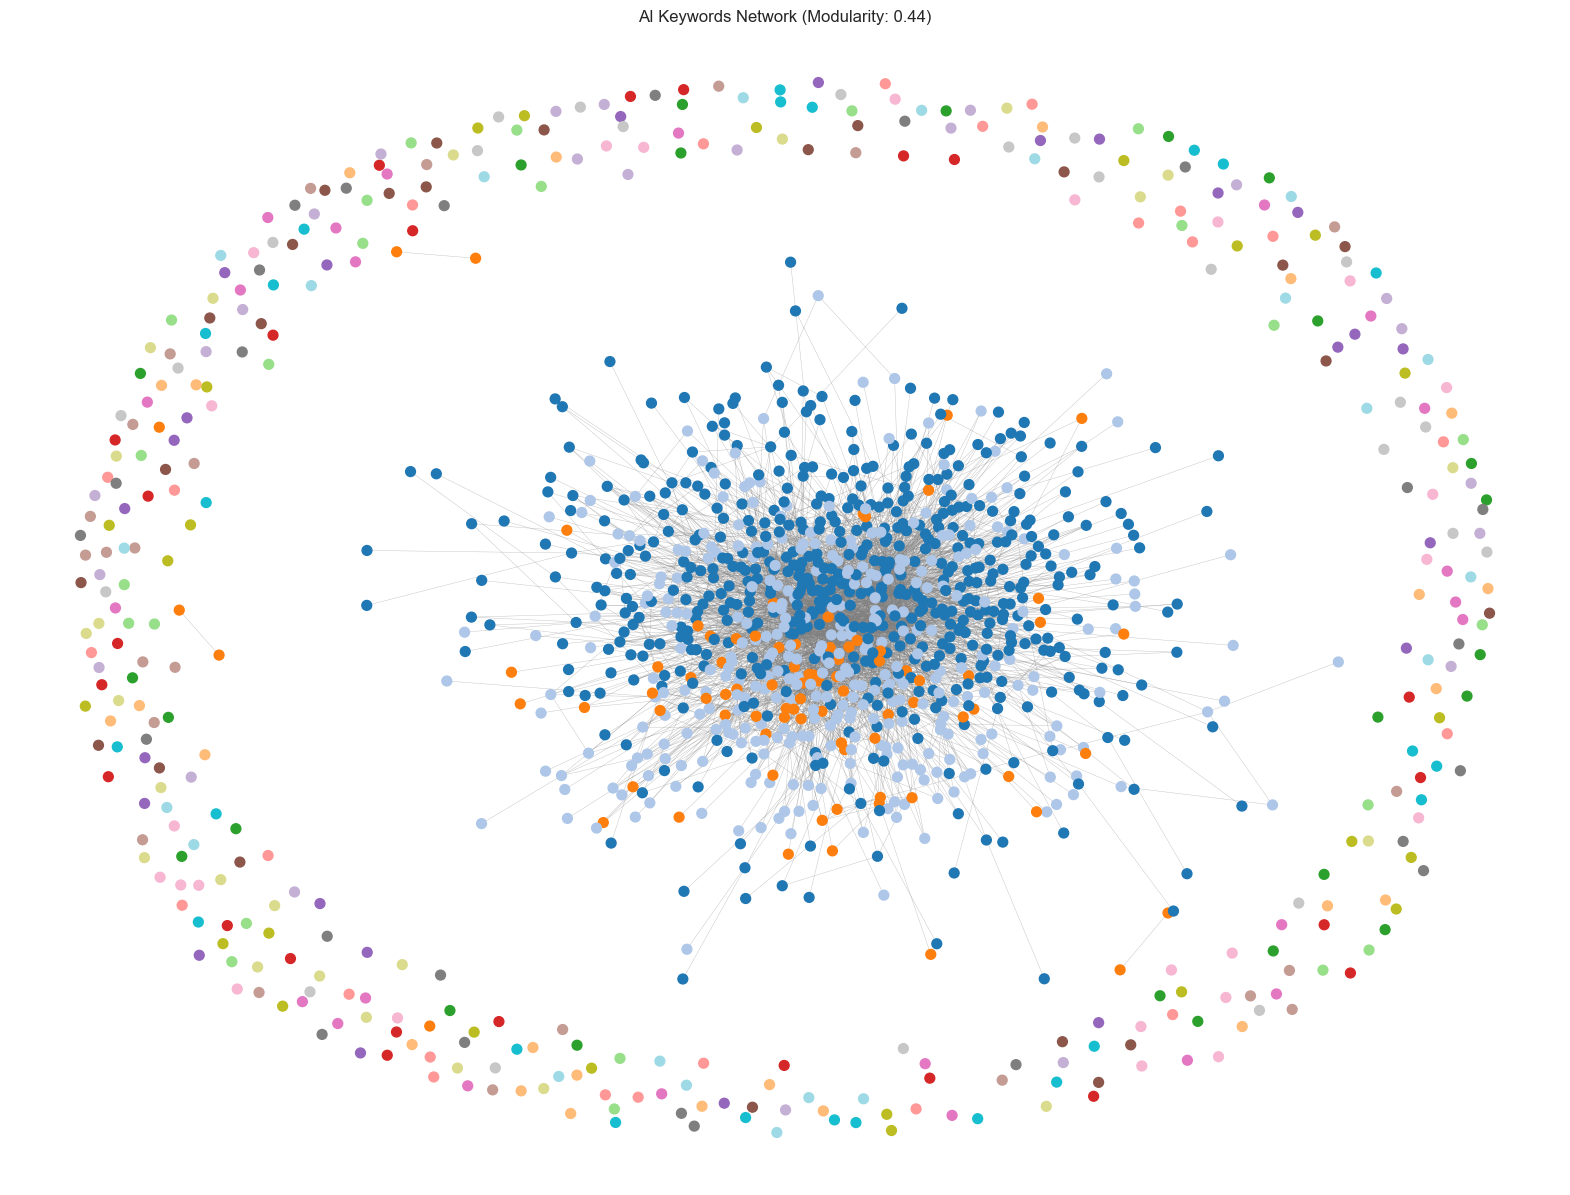

In [17]:
    # Визуализация
# analyzer.visualize_with_cosmograph()
analyzer.visualize_with_networkx()

Модулярность 0.436 — ниже оптимального (0.5-0.7), что говорит о умеренной структурированности.
Минимальный размер кластера = 3
Средний размер = 17.3
Тематическая чистота топовых кластеров (LLM, Data, Reasoning) — группировка логична.

In [22]:
detailed_stats = analyzer.get_detailed_stats()
print(detailed_stats[['cluster_id', 'size', 'top_keywords', 'avg_betweenness', 'avg_degree']].to_string(index=False))

 cluster_id  size                                                         top_keywords  avg_betweenness  avg_degree
          0   178                                    ai, multi, human, agents, systems         0.001238    0.006261
          1   139                         data, detection, dataset, training, features         0.001172    0.006725
          2   118                            models, llm, reasoning, large, evaluation         0.001173    0.007025
          3   113                           image, level, benchmark, video, multimodal         0.001037    0.006579
          4   109 learning, based, optimization, reinforcement learning, reinforcement         0.001072    0.006229
          5    85                                   llms, fine, efficient, tasks, task         0.001138    0.007425
          6    80                      model, generation, knowledge, prediction, graph         0.001177    0.007111
          7    70                         analysis, network, neural, mac

### Degree Centrality:
В вашем случае максимум **0.007** (у кластера 5) — это нормально для графа с 1381 узлом.  
**Пример расчета:**  
Degree Centrality = (число связей узла) / (N - 1)

где `N` = 1381 (общее число узлов).  

Для узла с 10 связями:  
10 / (1381 - 1) ≈ 0.00725




---

### Betweenness Centrality:
Значения близки к нулю, потому что:
- **Нет ярко выраженных "хабов"** между кластерами.  
- **Кратчайшие пути** между узлами проходят в основном **внутри кластеров**, а не через "мосты".  



In [19]:

class PaperNetwork:
    def __init__(self, csv_path: str):
        self.df = pd.read_csv(csv_path)
        self.df['keywords'] = self.df['keywords'].str.split(', ')
        self.G = nx.Graph()
        self._build_network()

    def _build_network(self, min_common_keywords: int = 1):
        """Строит граф публикаций на основе общих ключевых слов"""
        # Добавляем узлы
        for _, row in self.df.iterrows():
            self.G.add_node(row.name,
                           title=row['title'],
                           authors=row['authors'],
                           keywords=row['keywords'])
        
        # Создаем индекс ключевое слово -> публикации
        keyword_index = {}
        for idx, keywords in self.df['keywords'].items():
            for kw in keywords:
                keyword_index.setdefault(kw.strip(), []).append(idx)
        
        # Добавляем ребра на основе общих ключевых слов
        for kw, papers in keyword_index.items():
            for p1, p2 in combinations(papers, 2):
                weight = self.G.get_edge_data(p1, p2, {'weight': 0})['weight']
                self.G.add_edge(p1, p2, weight=weight + 1)

        # Фильтруем слабые связи
        to_remove = [(u, v) for u, v, d in self.G.edges(data=True) if d['weight'] < min_common_keywords]
        self.G.remove_edges_from(to_remove)

    def find_similar_papers(self, paper_id: int, top_n: int = 5):
        """Находит наиболее близкие публикации"""
        if paper_id not in self.G:
            raise ValueError(f"Публикация с ID {paper_id} не найдена")
        
        # Собираем все связи с учетом весов
        similarities = []
        for neighbor in self.G.neighbors(paper_id):
            weight = self.G[paper_id][neighbor]['weight']
            similarities.append((neighbor, weight))
        
        # Сортируем по убыванию веса
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # Формируем результат
        result = []
        for pid, score in similarities[:top_n]:
            result.append({
                'id': pid,
                'title': self.G.nodes[pid]['title'],
                'common_keywords': score,
                'authors': self.G.nodes[pid]['authors']
            })
        
        target_title = self.G.nodes[paper_id]['title'][:50] + '...'
        print(f"\nТоп-{top_n} похожих на публикацию: '{target_title}({paper_id})'\n")
        return pd.DataFrame(result)

    def visualize_ego_network(self, paper_id: int, depth: int = 1):
        target_title = self.G.nodes[paper_id]['title'][:50] + '...'
        """Визуализирует локальную сеть вокруг публикации"""
        ego = nx.ego_graph(self.G, paper_id, radius=depth)
        pos = nx.spring_layout(ego)
        
        plt.figure(figsize=(12, 8))
        nx.draw(ego, pos, 
               node_size=50, 
               node_color='skyblue', 
               edge_color='gray',
               with_labels=False)
        
        # Подписи для целевого узла
        nx.draw_networkx_labels(ego, pos, {paper_id: str(paper_id)})
        
        # Интерактивные аннотации
        annot = plt.annotate("", xy=(0,0), xytext=(20,20),
                            textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w"),
                            arrowprops=dict(arrowstyle="->"))
        annot.set_visible(False)
        
        def update_annot(ind):
            node = list(ego.nodes)[ind["ind"][0]]
            annot.xy = pos[node]
            text = f"ID: {node}\nTitle: {self.G.nodes[node]['title'][:50]}..."
            annot.set_text(text)
        
        def hover(event):
            vis = annot.get_visible()
            if event.inaxes == ax:
                cont, ind = ego.contains(event)
                if cont:
                    update_annot(ind)
                    annot.set_visible(True)
                    plt.draw()
                else:
                    if vis:
                        annot.set_visible(False)
                        plt.draw()
        
        ax = plt.gca()
        plt.connect("motion_notify_event", hover)
        plt.title(f"Сеть вокруг публикации {target_title} ({paper_id})")
        plt.show()

In [20]:

# Инициализация сети
pn = PaperNetwork('ai_papers_with_keywords.csv')

# Поиск похожих статей
paper_id = 42  # Можно выбрать любой ID из данных
similar = pn.find_similar_papers(paper_id)

print(similar[['id', 'common_keywords', 'title']].to_string(index=False))


Топ-5 похожих на публикацию: 'ConceptFormer: Towards Efficient Use of Knowledge-...(42)'

 id  common_keywords                                                                                                                                 title
 98                4                                       KG-LLM-Bench: A Scalable Benchmark for Evaluating LLM Reasoning on Textualized Knowledge Graphs
306                4                                Evaluating Knowledge Graph Based Retrieval Augmented Generation Methods under Knowledge Incompleteness
394                4                                            Hierarchical Planning for Complex Tasks with Knowledge Graph-RAG and Symbolic Verification
439                4 Crowdsourcing-Based Knowledge Graph Construction for Drug Side Effects Using Large Language Models with an Application on Semaglutide
127                3                                                                               FamilyTool: A Multi-hop Personalize

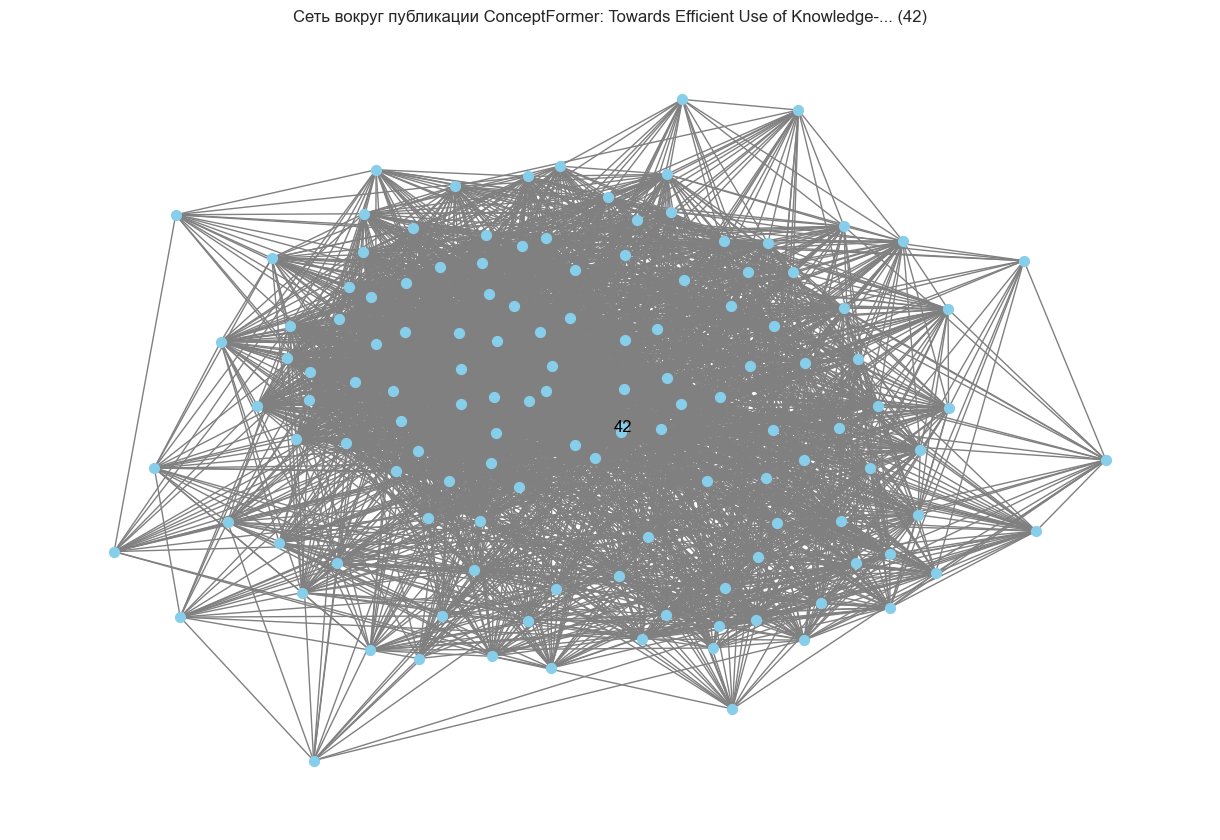

In [21]:
# Визуализация
pn.visualize_ego_network(paper_id)